# Анализ времени работы алгоритмов сортировки
**Вариант 16**: структура «Абитуриент», алгоритмы: сортировка выбором, пирамидальная, слиянием, std::sort.  
Данные получены на массивах размером от 100 до 100 000 элементов.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Чтение данных
df = pd.read_csv('timing_results.csv')
df.head()

,size,selection,heap,merge,std_sort
0,100,0.000029,0.000032,0.000093,0.000027
1,200,0.000093,0.000071,0.000316,0.000039
2,500,0.000487,0.000176,0.000574,0.000086
3,1000,0.001846,0.000387,0.001383,0.000222
4,2000,0.008502,0.000893,0.002445,0.000447


## Исходные данные
Таблица содержит размер массива и время (в секундах) для четырёх методов:
- `selection` – сортировка выбором
- `heap` – пирамидальная сортировка
- `merge` – сортировка слиянием
- `std_sort` – стандартная сортировка C++ (std::sort)

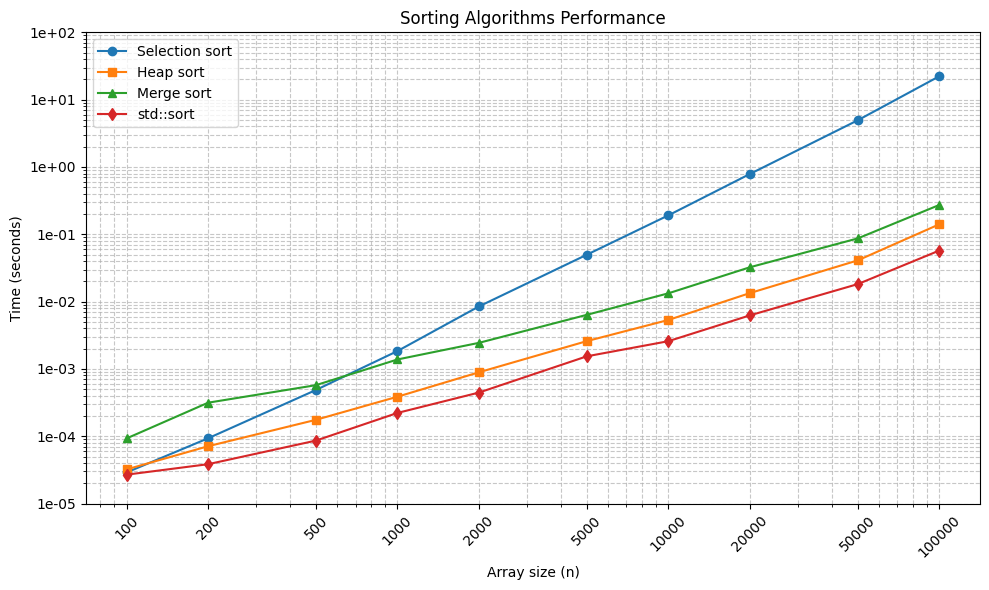

In [3]:
# Извлечение данных
# Из объекта df извлекается столбец, values преобразует столбец в массив NumPy
sizes = df['size'].values
selection = df['selection'].values
heap = df['heap'].values
merge = df['merge'].values
std_sort = df['std_sort'].values

# Создаёт новую фигуру (окно с графиком)
plt.figure(figsize=(10, 6))

# Строит линию (график) для каждой функции сортировки
plt.plot(sizes, selection, 'o-', label='Selection sort')
plt.plot(sizes, heap, 's-', label='Heap sort')
plt.plot(sizes, merge, '^-', label='Merge sort')
plt.plot(sizes, std_sort, 'd-', label='std::sort')

# Логарифмические шкалы
# Используются для того, чтобы наглядно представить данные, которые охватывают несколько порядков
# Расстояния становятся пропорциональны логарифмам, точки распределены равномернее, и форма кривых хорошо видна
plt.xscale('log')
plt.yscale('log')

# Метки по оси X – исходные размеры (повёрнутые)
plt.xticks(sizes, sizes.astype(str), rotation=45)

# Метки по оси Y – степени 10
y_ticks = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1, 1e2]
plt.yticks(y_ticks, [f'{tick:.0e}' for tick in y_ticks])

plt.xlabel('Array size (n)')
plt.ylabel('Time (seconds)')
plt.title('Sorting Algorithms Performance')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()

# Автоматически подгоняет элементы графика (оси, подписи, легенду), чтобы они не обрезались и не налезали друг на друга.
plt.tight_layout()
plt.savefig('sorting_plot.png', dpi=150)
plt.show()

### 1. Сортировка выбором (selection)

**Вид кривой:** на графике кривая резко уходит вверх, её наклон значительно круче, чем у остальных алгоритмов.  

**Интерпретация:** такое поведение соответствует квадратичной сложности O(n²), то есть при увеличении размера массива n время работы алгоритма растёт пропорционально квадрату n. Уже при относительно небольших размерах массива время работы начинает расти катастрофически быстро.Квадратичная сложность возникает из-за того, что на каждом шаге мы заново просматриваем почти весь массив для поиска минимального элемента в ещё неотсортированной части. 

**Рекомендация:**  
- Использовать только для очень маленьких массивов, когда разница во времени с другими методами незначительна. 
- На реальных данных (особенно при размерах более нескольких тысяч элементов) применять не рекомендуется - – время работы становится неприемлемо большим.

---

### 2. Пирамидальная сортировка (heap) и сортировка слиянием (merge)

**Вид кривых:** обе кривые имеют пологий подъём, наклон чуть больше 1. Кривая heap на всём диапазоне проходит **ниже** кривой merge.  

**Интерпретация:**  
- Пологий подъём соответствует сложности O(n log n). В логарифмических координатах такая зависимость даёт не прямую, а слегка изогнутую линию. Кривая растёт медленнее, чем квадратичная, но чуть быстрее, чем линейная  
- Heap быстрее merge, так как не требует выделения дополнительной памяти и копирования данных. Heap sort использует только исходный массив, Merge sort при слиянии создаёт временные векторы L и R, копирует в них данные из исходного массива, а затем копирует обратно.
- Merge sort стабильна. Стабильность сортировки означает, что если два элемента имеют одинаковые значения, по которым происходит сравнение, их относительный порядок в исходном массиве сохраняется в отсортированном. При слиянии двух подмассивов, если элементы равны, алгоритм берёт сначала элемент из левой половины. Это гарантирует, что порядок равных элементов из левой части сохраняется относительно правой. В Heap sort при обменах и просеивании равные элементы могут оказаться в любом порядке относительно друг друга.

**Рекомендации:**  
- **Heap sort** выбирать, когда важна экономия памяти.  
- **Merge sort** применять, когда необходима стабильность.

---

### 3. std::sort

**Вид кривой:** кривая расположена **ниже всех остальных** на всём диапазоне размеров, наклон также пологий (O(n log n)).  

**Интерпретация:** это самый быстрый алгоритм среди всех протестированных, имеет наилучшую производительность

**Рекомендация:**  
-  Универсальный, высокооптимизированный и надёжный выбор для любых массивов, если нет специальных ограничений.

---

### Заключение

Построенные графики наглядно демонстрируют:
- **Сортировка выбором** – квадратичная сложность, непригодна для больших объёмов данных.  
- **Heap sort** – предпочтительнее merge sort при ограниченной памяти.  
- **Merge sort** – незаменим при стабильности.  
- **`std::sort`** – абсолютный лидер по скорости.  

Выбор конкретного алгоритма должен определяться приоритетами задачи: скорость (std::sort), экономия памяти (heap) или стабильность (merge). Полученные графики служат визуальным подтверждением этих рекомендаций.